In [1]:
import uuid
from dotenv import load_dotenv
from modules import logging
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import OllamaEmbeddings
from langchain_openai import ChatOpenAI
from langchain.retrievers.multi_query import MultiQueryRetriever
from langchain.schema import BaseMessage
from typing_extensions import Annotated, Literal, Sequence, TypedDict
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
import pprint
from langchain_core.runnables import RunnableConfig

In [2]:
# LangSmith Logging
logging.langsmith("Model_RAG")
# API 키 정보 로드
load_dotenv()

LangSmith 추적을 시작합니다.
[프로젝트명]
Model_RAG


True

In [3]:
session_id = str(uuid.uuid4())
memory = MemorySaver()

In [4]:
ollama_embeddings = OllamaEmbeddings(
    model="nomic-embed-text"
)

loaded_db = FAISS.load_local(
    folder_path="faiss_db",
    index_name="meritz_index",
    embeddings=ollama_embeddings,
    allow_dangerous_deserialization=True,
)

C:\Users\vkxql\AppData\Local\Temp\ipykernel_4036\4185708034.py:1: LangChainDeprecationWarning: The class `OllamaEmbeddings` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import OllamaEmbeddings``.
  ollama_embeddings = OllamaEmbeddings(


In [5]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [6]:
multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=loaded_db.as_retriever(),
    llm=llm
)

In [7]:
class state(TypedDict):
    # 메시지 관리 (사용자와 시스템의 대화 기록)
    messages: Annotated[Sequence[BaseMessage], "add_messages"]
    # 세션 ID (각 워크플로우 인스턴스에 고유한 ID)
    session_id: str
    # 기타 메타데이터 (사용자 정보, 소스 등)
    metadata: dict
    # 검색된 문서 리스트
    retrieved_docs: dict  # 검색 결과 (MultiQueryRetriever의 반환 값)
    # 등급
    document_grading: list
    # 재 생성 된 답변
    rewritten_question : list
    # 생성된 최종 답변
    generated_response: str  # 시스템의 최종 답변

In [8]:
# Agent 노드

def agent(state: state) -> state:
    """
    Invoke the agent model to generate a response based on the current state, given
    The problem is to search using the multi-query retriever tool for your question {} or, if it's not about car insurance, answer "I don't know" and decide to simply exit.

    Args:
    Status (message): current status

    Return:
    dict: Updated status with agent response added to message
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    rewritten_question = state.get("rewritten_question", None)
    model = ChatOpenAI(temperature=0, streaming=True, model="gpt-4o-mini")
    
    # rewritten_question이 있으면 응답 변경
    if rewritten_question:
        response = model.invoke(rewritten_question)
    else:
        pass
        
    # model = model.bind_tools(tools)
    response = model.invoke(messages)
    print("State contents:", state)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

In [9]:
def retriever_tool(state:state) -> state:
    """
    It's a multi-query retriever tool
    Retrieves documents using MultiQueryRetriever based on the current question.
    """
    print("---CALL RETRIEVE TOOL---")
    
    # 사용자의 마지막 질문 또는 rewritten_question이 있는 경우 해당 값을 사용
    # user_question = state["messages"][-1]["content"]
    messages = state["messages"]
    user_question = messages[-1]
    
    # MultiQueryRetriever에 사용할 프롬프트
    multi_query_prompt = f"""
    You are an expert assistant trained to optimize search queries for retrieving the most relevant documents.
    Given a user question, your task is to generate multiple rephrased versions of the same question. These
    rephrased questions should:
    
    1. Cover different ways a user might phrase the same question.
    2. Maintain the original intent and meaning of the question.
    3. Use synonyms, structural variations, and alternative expressions where applicable.

    For the following user question, generate at least **5 rephrased versions**:
    
    Original Question:
    "{user_question}"
    
    Ensure your rephrased versions are concise, clear, and ready to be used in a search query. Output the rephrased questions as a list.
    """
    
    # MultiQueryRetriever로 문서 검색
    retrieved_docs = multi_query_retriever.get_relevant_documents(multi_query_prompt)
    
    # 검색된 문서를 상태에 저장
    state["retrieved_docs"] = retrieved_docs
    return state

In [10]:
def grade_documents(state: state) -> state:
    """
    Grades the retrieved documents to determine relevance to the user's question.
    """
    print("---GRADE DOCUMENTS NODE ACTIVATED---")
    
    retrieved_docs = state.get("retrieved_docs", [])
    user_question = state["messages"][-1]["content"]
    
    grading_prompt = f"""
    You are an expert in evaluating document relevance. Given the user's question and the retrieved documents,
    evaluate whether the documents are relevant or Not Relevant.

    User Question:
    "{user_question}"

    Retrieved Documents (Summarized):
    {retrieved_docs}

    Respond with:
    - "Relevant" if the documents are relevant to the question.
    - "Not Relevant" if the documents are not relevant.
    """
    
    # LLM 평가
    relevance_result = llm(grading_prompt)
    state["document_grading"] = relevance_result.strip().lower()
    print(f"Document Grading: {state['document_grading']}")
    return state

In [11]:
# 조건부 연결 추가
def conditional_decision(state: state) -> state:
    """
    조건부 경로를 결정하는 함수.
    'grade_documents' 결과에 따라 경로가 나뉨.
    """
    if state.get("document_grading") == "relevant":
        return "generate"
    else:
        return "rewrite"

In [12]:
def rewrite(state: state) -> state:
    """
    Generates a new question if the retrieved documents are not relevant.
    """
    print("---REWRITE NODE ACTIVATED---")
    
    user_question = state["messages"][-1]["content"]
    rewrite_prompt = f"""
    The retrieved documents were not relevant to the following user question:
    "{user_question}"
    
    Please analyze the user's intent and generate a new question that better represents the user's intent
    to find relevant documents. Ensure the new question is concise and clear.
    """
    
    # LLM을 사용하여 질문 재작성
    rewritten_question = llm(rewrite_prompt)
    state["rewritten_question"] = rewritten_question.strip()
    print(f"Rewritten Question: {state['rewritten_question']}")
    return state

In [13]:
def generate(state: state) -> state:
    """
    Generates the final response based on the user's question and relevant documents.
    """
    print("---GENERATE RESPONSE NODE ACTIVATED---")
    
    user_question = state["messages"][-1]["content"]
    retrieved_docs = state["retrieved_docs"]
    
    # LLM
    llm = ChatOpenAI(model_name="gpt-4o-mini", temperature=0, streaming=True)
    
    response_prompt = f"""
    User Question:
    "{user_question}"
    
    Relevant Documents:
    {retrieved_docs}
    
    Generate a concise and accurate response to the user's question based on the provided information.
    Ensure the response directly addresses the question without adding unnecessary details. Focus on clarity and accuracy when interpreting the information and constructing the reply.

    # Steps

    1. Read and understand the user's question to identify the key components and what needs to be addressed.
    2. Review the provided information carefully to ensure no important details are overlooked.
    3. Interpret the information in the context of the question.
    4. Construct a clear and concise response that directly answers the user's question, ensuring all necessary aspects are covered.

    # Output Format

    The response should be a short paragraph or bullet points, depending on the complexity and nature of the question. Aim for brevity and clarity.
    """
    
    
    # LLM을 사용하여 최종 답변 생성
    generated_response = llm(response_prompt)
    state["generated_response"] = generated_response.strip()
    print(f"Generated Response: {state['generated_response']}")
    
    rag_chain = generated_response | StrOutputParser()
    
    response = rag_chain.invoke({"context": retrieved_docs, "question": user_question})
    return {"messages": [response]}


In [14]:
workflow = StateGraph(state)

In [15]:
workflow.add_node("agent", agent)
workflow.add_node("retriever", retriever_tool)
workflow.add_node("grade", grade_documents)
workflow.add_node("rewrite", rewrite)
workflow.add_node("generate", generate)

In [16]:
workflow.add_edge(START, "agent")
workflow.add_edge("agent", "retriever")
workflow.add_edge("retriever", "grade")
workflow.add_conditional_edges(
    "grade",
    # Assess agent decision
    conditional_decision,
)
workflow.add_edge("rewrite", "agent")
workflow.add_edge("generate", END)

In [17]:
graph = workflow.compile(checkpointer=memory)

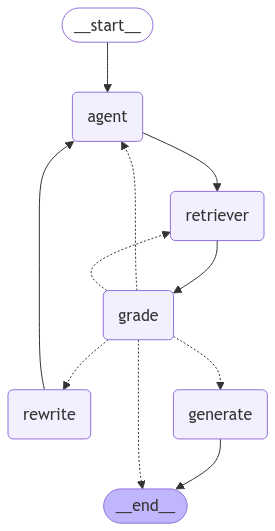

In [18]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [19]:
import pprint

# 입력 데이터 정의
inputs = {
    "messages": [
        ("user", "대인 부분 약관과 보장 범위에 대해 알려줘."),
    ]
}

# Configurable 설정 (필요한 경우)
config = {"configurable": {"thread_id": "user_123"}}

# 그래프 스트림 실행
for output in graph.stream(inputs, config=config):
    # 각 노드의 출력 처리
    for key, value in output.items():
        print(f"\n{'-'*10} Output from node '{key}' {'-'*10}\n")
        
        # 메시지가 포함된 경우만 출력
        if "messages" in value:
            for message in value["messages"]:
                if hasattr(message, "content") and message.content:
                    print(f"**Message Content**:\n{message.content}\n")
        else:
            pprint.pprint(value, indent=2, width=80, depth=None)
        
        print("\n" + "-"*30 + "\n")


---CALL AGENT---
State contents: {'messages': [('user', '대인 부분 약관과 보장 범위에 대해 알려줘.')]}

---------- Output from node 'agent' ----------

**Message Content**:
대인 부분 약관과 보장 범위는 보험 상품에 따라 다를 수 있지만, 일반적으로 대인 보험은 타인에게 발생한 신체적 피해에 대한 보장을 제공합니다. 대인 부분의 주요 내용은 다음과 같습니다.

1. **보장 범위**:
   - **신체 상해**: 사고로 인해 타인이 다쳤을 경우, 치료비, 입원비, 재활비 등을 보장합니다.
   - **사망**: 사고로 인해 타인이 사망한 경우, 유족에게 지급되는 보상금이 포함됩니다.
   - **법적 비용**: 사고로 인해 발생한 법적 분쟁에 대한 변호사 비용이나 소송 비용을 보장할 수 있습니다.

2. **면책 사항**:
   - 고의적인 행위로 인한 피해는 보장되지 않을 수 있습니다.
   - 보험 계약자가 음주 운전이나 약물 복용 상태에서 사고를 일으킨 경우, 보장이 제한될 수 있습니다.
   - 특정 상황(예: 무면허 운전)에서는 보장이 적용되지 않을 수 있습니다.

3. **보험 한도**:
   - 대인 보험은 보장 한도가 설정되어 있으며, 이 한도 내에서만 보상이 이루어집니다. 한도를 초과하는 금액은 보험 가입자가 부담해야 합니다.

4. **보험료**:
   - 대인 보험의 보험료는 보장 범위, 한도, 가입자의 운전 이력 등에 따라 달라질 수 있습니다.

각 보험사마다 약관이 다를 수 있으므로, 구체적인 내용은 해당 보험사의 약관을 확인하는 것이 중요합니다. 필요시 보험 상담사와 상담하여 자세한 정보를 얻는 것도 좋은 방법입니다.


------------------------------

---CALL RETRIEVE TOOL---


C:\Users\vkxql\AppData\Local\Temp\ipykernel_4036\2156892411.py:31: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  retrieved_docs = multi_query_retriever.get_relevant_documents(multi_query_prompt)



---------- Output from node 'retriever' ----------

**Message Content**:
대인 부분 약관과 보장 범위는 보험 상품에 따라 다를 수 있지만, 일반적으로 대인 보험은 타인에게 발생한 신체적 피해에 대한 보장을 제공합니다. 대인 부분의 주요 내용은 다음과 같습니다.

1. **보장 범위**:
   - **신체 상해**: 사고로 인해 타인이 다쳤을 경우, 치료비, 입원비, 재활비 등을 보장합니다.
   - **사망**: 사고로 인해 타인이 사망한 경우, 유족에게 지급되는 보상금이 포함됩니다.
   - **법적 비용**: 사고로 인해 발생한 법적 분쟁에 대한 변호사 비용이나 소송 비용을 보장할 수 있습니다.

2. **면책 사항**:
   - 고의적인 행위로 인한 피해는 보장되지 않을 수 있습니다.
   - 보험 계약자가 음주 운전이나 약물 복용 상태에서 사고를 일으킨 경우, 보장이 제한될 수 있습니다.
   - 특정 상황(예: 무면허 운전)에서는 보장이 적용되지 않을 수 있습니다.

3. **보험 한도**:
   - 대인 보험은 보장 한도가 설정되어 있으며, 이 한도 내에서만 보상이 이루어집니다. 한도를 초과하는 금액은 보험 가입자가 부담해야 합니다.

4. **보험료**:
   - 대인 보험의 보험료는 보장 범위, 한도, 가입자의 운전 이력 등에 따라 달라질 수 있습니다.

각 보험사마다 약관이 다를 수 있으므로, 구체적인 내용은 해당 보험사의 약관을 확인하는 것이 중요합니다. 필요시 보험 상담사와 상담하여 자세한 정보를 얻는 것도 좋은 방법입니다.


------------------------------

---GRADE DOCUMENTS NODE ACTIVATED---


TypeError: 'AIMessage' object is not subscriptable

In [41]:
from modules.messages import _display_message_tree

In [42]:
_display_message_tree(output)

[agent]:
    [messages]:
        messages[0]:
            messages[0]: content='대인 부분 약관과 보장 범위는 보험 상품에 따라 다를 수 있지만, 일반적으로 대인 보험은 사고로 인해 타인에게 발생한 신체적 피해에 대한 보장을 제공합니다. 대인 부분의 주요 내용은 다음과 같습니다.\n\n1. **보장 범위**:\n   - **신체 상해**: 사고로 인해 타인이 다치거나 사망했을 경우, 그에 대한 치료비, 장례비, 위자료 등을 보장합니다.\n   - **법적 비용**: 사고로 인해 발생한 법적 분쟁에 대한 변호사 비용 및 소송 비용을 포함할 수 있습니다.\n   - **배상 책임**: 사고로 인해 발생한 손해에 대해 법적으로 배상해야 할 책임을 보장합니다.\n\n2. **약관의 주요 내용**:\n   - **보장 한도**: 보험사가 보장하는 최대 금액이 명시되어 있습니다.\n   - **면책 사항**: 특정 상황에서는 보장이 이루어지지 않을 수 있으며, 이러한 면책 사항이 약관에 명시되어 있습니다.\n   - **보험료**: 대인 보험에 대한 보험료는 보장 범위와 한도에 따라 달라질 수 있습니다.\n   - **청구 절차**: 사고 발생 시 보험금을 청구하는 방법과 필요한 서류에 대한 안내가 포함되어 있습니다.\n\n각 보험사마다 약관과 보장 범위가 다를 수 있으므로, 구체적인 내용은 해당 보험사의 약관을 확인하는 것이 중요합니다.' additional_kwargs={} response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_bba3c8e70b'} id='run-df7df888-8e26-40fc-b31f-66f6a752b7db-0'
